In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
## Loading in datasets

itu = pd.read_csv(
    "../data/interim/itu_final_candidates_2018_2024.csv"
)

electricity = pd.read_csv(
    "../data/raw/API_EG.ELC.ACCS.ZS_DS2_en_csv_v2_367283.csv",
    skiprows=4
)

classifications = pd.read_csv(
    "../data/raw/nations_incomes_2026_07_15.csv"
)

In [4]:
print(itu.shape)
print(electricity.shape)
print(classifications.shape)

(1016, 15)
(265, 71)
(268, 5)


In [6]:
final_temp_countries = itu["AreaName"].unique()

final_temp_countries

array(['Afghanistan', 'Angola', 'Armenia', 'Burkina Faso', 'Botswana',
       'Barbados', 'Cambodia', 'Colombia', 'Spain', 'Ethiopia',
       'Honduras', 'India', 'Indonesia', 'Iraq', 'Israel', 'Japan',
       'Jamaica', 'Kenya', 'Madagascar', 'Morocco', 'Papua New Guinea',
       'Rwanda', 'Uganda', 'Ukraine', 'United States'], dtype=object)

In [7]:
len(final_temp_countries)

25

In [8]:
electricity_final = electricity[electricity["Country Name"].isin(final_temp_countries)].copy()

electricity_final["Country Name"].unique()

array(['Afghanistan', 'Angola', 'Armenia', 'Burkina Faso', 'Barbados',
       'Botswana', 'Colombia', 'Spain', 'Ethiopia', 'Honduras',
       'Indonesia', 'India', 'Iraq', 'Israel', 'Jamaica', 'Japan',
       'Kenya', 'Cambodia', 'Morocco', 'Madagascar', 'Papua New Guinea',
       'Rwanda', 'Uganda', 'Ukraine', 'United States'], dtype=object)

In [9]:
electricity_final["Country Name"].nunique()

25

In [11]:
# Melting the electricity dataframe into a better form for conducting the analysis

year_cols = [str(year) for year in range(2018,2025)]

electricity_melted_final = electricity_final.melt(
    id_vars=["Country Name", "Country Code"],
    value_vars= year_cols,
    var_name= "Year",
    value_name="Electricity_Access"
)

In [12]:
electricity_melted_final["Year"] = electricity_melted_final["Year"].astype(int)

In [13]:
electricity_melted_final.shape

(175, 4)

In [14]:
electricity_melted_final.head(10)

,Country Name,Country Code,Year,Electricity_Access
0,Afghanistan,AFG,2018,93.4
1,Angola,AGO,2018,45.3
2,Armenia,ARM,2018,99.9
3,Burkina Faso,BFA,2018,14.4
4,Barbados,BRB,2018,100.0
5,Botswana,BWA,2018,68.3
6,Colombia,COL,2018,98.5
7,Spain,ESP,2018,100.0
8,Ethiopia,ETH,2018,44.8
9,Honduras,HND,2018,91.6


In [17]:
# Transforming the world income data

classifications_final = classifications[["Code", "Region", "Income group"]].copy()

In [19]:
electricity_merged = electricity_melted_final.merge(
    classifications_final,
    left_on="Country Code",
    right_on="Code",
    how="left"
)

In [20]:
electricity_merged.shape

(175, 7)

In [21]:
electricity_merged.head(10)

,Country Name,Country Code,Year,Electricity_Access,Code,Region,Income group
0,Afghanistan,AFG,2018,93.4,AFG,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Angola,AGO,2018,45.3,AGO,Sub-Saharan Africa,Lower middle income
2,Armenia,ARM,2018,99.9,ARM,Europe & Central Asia,Upper middle income
3,Burkina Faso,BFA,2018,14.4,BFA,Sub-Saharan Africa,Low income
4,Barbados,BRB,2018,100.0,BRB,Latin America & Caribbean,High income
5,Botswana,BWA,2018,68.3,BWA,Sub-Saharan Africa,Upper middle income
6,Colombia,COL,2018,98.5,COL,Latin America & Caribbean,Upper middle income
7,Spain,ESP,2018,100.0,ESP,Europe & Central Asia,High income
8,Ethiopia,ETH,2018,44.8,ETH,Sub-Saharan Africa,Low income
9,Honduras,HND,2018,91.6,HND,Latin America & Caribbean,Lower middle income


In [22]:
electricity_merged = electricity_merged.drop(columns=["Code"])

In [23]:
electricity_merged.head(10)

,Country Name,Country Code,Year,Electricity_Access,Region,Income group
0,Afghanistan,AFG,2018,93.4,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Angola,AGO,2018,45.3,Sub-Saharan Africa,Lower middle income
2,Armenia,ARM,2018,99.9,Europe & Central Asia,Upper middle income
3,Burkina Faso,BFA,2018,14.4,Sub-Saharan Africa,Low income
4,Barbados,BRB,2018,100.0,Latin America & Caribbean,High income
5,Botswana,BWA,2018,68.3,Sub-Saharan Africa,Upper middle income
6,Colombia,COL,2018,98.5,Latin America & Caribbean,Upper middle income
7,Spain,ESP,2018,100.0,Europe & Central Asia,High income
8,Ethiopia,ETH,2018,44.8,Sub-Saharan Africa,Low income
9,Honduras,HND,2018,91.6,Latin America & Caribbean,Lower middle income


In [24]:
# Merging ITU data into the frame to have a complete dataset to analyze 
itu_wide = itu.pivot(
    index=["AreaName", "AreaCode", "Year"],
    columns="Series",
    values="Value"
).reset_index()

In [26]:
print(itu_wide.shape)
itu_wide.head(10)

(175, 9)


Series,AreaName,AreaCode,Year,Active mobile-broadband subscriptions,Estimated proportion of households with Internet access at home,Fixed-broadband subscriptions,Internet users (%),Percentage of the population covered by at least an LTE/WiMAX mobile network.,Population
0,Afghanistan,AFG,2018,6997208.0,7.270304,15999.0,16.799999,7.000000,36743039.0
1,Afghanistan,AFG,2019,7309797.0,8.438115,19683.0,17.600000,22.000000,37856121.0
2,Afghanistan,AFG,2020,7422550.0,NaN,26570.0,17.048500,26.000000,39068979.0
3,Afghanistan,AFG,2021,7422550.0,24.288903,26570.0,16.514299,26.000000,40000412.0
4,Afghanistan,AFG,2022,22831896.0,27.592028,32313.0,15.866300,33.030000,40578842.0
5,Afghanistan,AFG,2023,23027082.0,27.700000,33200.0,15.928400,34.000000,41454761.0
6,Afghanistan,AFG,2024,25630751.0,27.989760,NaN,16.094999,37.324101,42647492.0
7,Angola,AGO,2018,5820154.0,6.711401,109561.0,29.000000,8.000000,31297155.0
8,Angola,AGO,2019,6740418.0,8.016441,119068.0,32.129398,18.000000,32375632.0
9,Angola,AGO,2020,6637340.0,35.390813,121516.0,33.320900,72.740000,33451132.0


In [27]:
analysis_df = itu_wide.merge(
    electricity_merged,
    left_on=["AreaCode", "Year"],
    right_on=["Country Code", "Year"],
    how="left"
)

In [28]:
print(analysis_df.shape)
analysis_df.head()

(175, 14)


,AreaName,AreaCode,Year,Active mobile-broadband subscriptions,Estimated proportion of households with Internet access at home,Fixed-broadband subscriptions,Internet users (%),Percentage of the population covered by at least an LTE/WiMAX mobile network.,Population,Country Name,Country Code,Electricity_Access,Region,Income group
0,Afghanistan,AFG,2018,6997208.0,7.270304,15999.0,16.799999,7.00,36743039.0,Afghanistan,AFG,93.4,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,Afghanistan,AFG,2019,7309797.0,8.438115,19683.0,17.600000,22.00,37856121.0,Afghanistan,AFG,97.7,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,Afghanistan,AFG,2020,7422550.0,NaN,26570.0,17.048500,26.00,39068979.0,Afghanistan,AFG,97.7,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,Afghanistan,AFG,2021,7422550.0,24.288903,26570.0,16.514299,26.00,40000412.0,Afghanistan,AFG,97.7,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,Afghanistan,AFG,2022,22831896.0,27.592028,32313.0,15.866300,33.03,40578842.0,Afghanistan,AFG,85.3,"Middle East, North Africa, Afghanistan & Pakistan",Low income


In [29]:
analysis_df["Electricity_Access"].isna().sum()

0

## Official start of the EDA


In [30]:
analysis_df.isna().sum()

AreaName                                                                          0
AreaCode                                                                          0
Year                                                                              0
Active mobile-broadband subscriptions                                             7
Estimated proportion of households with Internet access at home                  14
Fixed-broadband subscriptions                                                     8
Internet users (%)                                                                1
Percentage of the population covered by at least an LTE/WiMAX mobile network.     5
Population                                                                        0
Country Name                                                                      0
Country Code                                                                      0
Electricity_Access                                                          

In [ ]:
# Using to calculate how much of the data is missing for analysis
analysis_df_pct = (analysis_df.isna().sum() / len(analysis_df)) * 100

In [32]:
analysis_df_pct.round(2)

AreaName                                                                         0.00
AreaCode                                                                         0.00
Year                                                                             0.00
Active mobile-broadband subscriptions                                            4.00
Estimated proportion of households with Internet access at home                  8.00
Fixed-broadband subscriptions                                                    4.57
Internet users (%)                                                               0.57
Percentage of the population covered by at least an LTE/WiMAX mobile network.    2.86
Population                                                                       0.00
Country Name                                                                     0.00
Country Code                                                                     0.00
Electricity_Access                                    

## Descriptive Stats

In [33]:
analysis_df.describe().round(2)

,Year,Active mobile-broadband subscriptions,Estimated proportion of households with Internet access at home,Fixed-broadband subscriptions,Internet users (%),Percentage of the population covered by at least an LTE/WiMAX mobile network.,Population,Electricity_Access
count,175.00,1.680000e+02,161.00,1.670000e+02,174.00,170.00,1.750000e+02,175.00
mean,2021.00,8.836655e+07,59.36,1.047880e+07,53.18,77.82,1.116423e+08,79.81
std,2.01,1.883401e+08,28.70,2.597302e+07,28.99,29.67,2.786527e+08,27.07
min,2018.00,1.150000e+05,3.40,7.501000e+03,7.40,0.00,2.807110e+05,14.40
25%,2019.00,5.245203e+06,30.46,1.058100e+05,22.95,65.61,1.033976e+07,55.35
50%,2021.00,1.703490e+07,67.58,4.957250e+05,57.98,94.80,3.695444e+07,97.70
75%,2023.00,3.658082e+07,85.35,7.768113e+06,80.35,98.99,5.119550e+07,100.00
max,2024.00,8.985695e+08,97.32,1.342230e+08,95.76,100.00,1.450936e+09,100.00


## Normalizing the subsciptions values

In [34]:
# % for Mobile broadband 
analysis_df["Mobile_Broadband_per_100"] = (
    analysis_df["Active mobile-broadband subscriptions"]
    / analysis_df["Population"]
) * 100

In [35]:
# % for Fixed-broadband

analysis_df["Fixed-broadband_per_100"] = (
    analysis_df["Fixed-broadband subscriptions"]
     / analysis_df["Population"]
) * 100

In [38]:
analysis_df[
    ["Mobile_Broadband_per_100", "Fixed-broadband_per_100"]
].describe().round(2)

,Mobile_Broadband_per_100,Fixed-broadband_per_100
count,168.00,167.00
mean,71.86,11.02
std,43.85,13.01
min,10.77,0.04
25%,40.97,0.39
50%,61.23,4.36
75%,98.56,17.23
max,249.10,45.44


## Visuals of Data

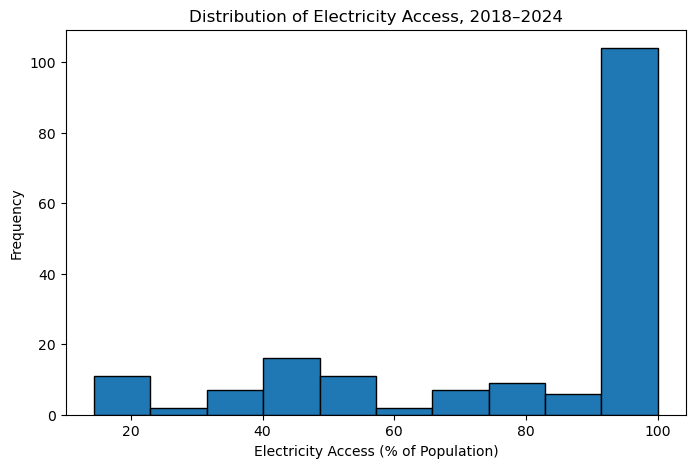

In [39]:
# Electricity Distributions
plt.figure(figsize=(8, 5))

plt.hist(
    analysis_df["Electricity_Access"].dropna(),
    bins=10,
    edgecolor="black"
)

plt.xlabel("Electricity Access (% of Population)")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Access, 2018–2024")

plt.show()

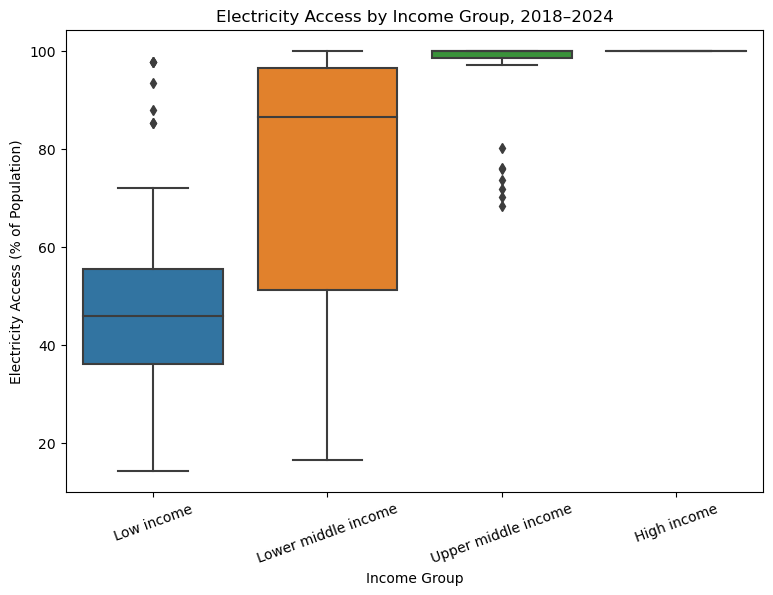

In [40]:
# Electricity access via income

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=analysis_df,
    x="Income group",
    y="Electricity_Access"
)

plt.xlabel("Income Group")
plt.ylabel("Electricity Access (% of Population)")
plt.title("Electricity Access by Income Group, 2018–2024")
plt.xticks(rotation=20)

plt.show()

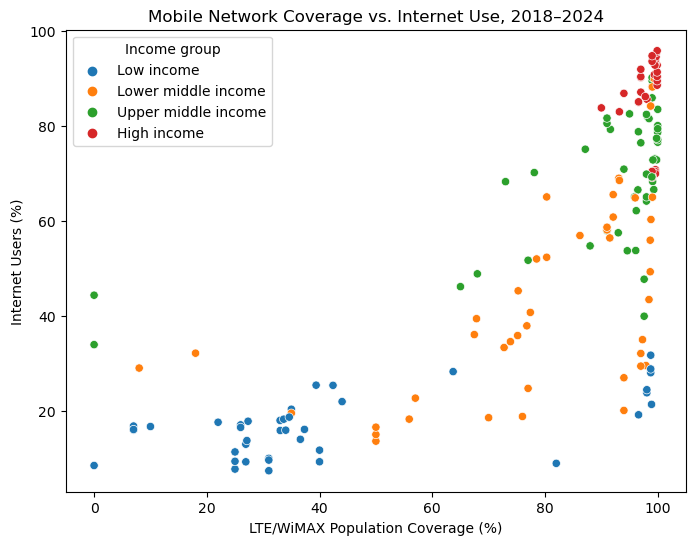

In [41]:
# LTE coverage compared to internet usage
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=analysis_df,
    x="Percentage of the population covered by at least an LTE/WiMAX mobile network.",
    y="Internet users (%)",
    hue="Income group"
)

plt.xlabel("LTE/WiMAX Population Coverage (%)")
plt.ylabel("Internet Users (%)")
plt.title("Mobile Network Coverage vs. Internet Use, 2018–2024")

plt.show()

## Calculating the correlations between metrics

In [42]:
analysis_df[
    [
        "Percentage of the population covered by at least an LTE/WiMAX mobile network.",
        "Internet users (%)"
    ]
].corr()

,Percentage of the population covered by at least an LTE/WiMAX mobile network.,Internet users (%)
Percentage of the population covered by at least an LTE/WiMAX mobile network.,1.000000,0.753997
Internet users (%),0.753997,1.000000


In [45]:
analysis_df["Coverage_Use_Gap"] = (
    analysis_df["Percentage of the population covered by at least an LTE/WiMAX mobile network."]
    - analysis_df["Internet users (%)"]
)

In [46]:
analysis_df[
    ["AreaName", "Year", "Income group", "Coverage_Use_Gap"]
].sort_values(
    by="Coverage_Use_Gap",
    ascending=False
).head(15)

,AreaName,Year,Income group,Coverage_Use_Gap
141,Rwanda,2019,Low income,77.542000
140,Rwanda,2018,Low income,77.433401
142,Rwanda,2020,Low income,74.270000
70,India,2018,Lower middle income,73.918700
143,Rwanda,2021,Low income,73.628399
160,Uganda,2024,Low income,73.050169
144,Rwanda,2022,Low income,70.743200
145,Rwanda,2023,Low income,69.954201
71,India,2019,Lower middle income,68.396500
116,Kenya,2022,Lower middle income,67.594101


## Temporal Analysis

In [47]:
gap_trend = (
    analysis_df
    .groupby(["Year", "Income group"], observed=True)["Coverage_Use_Gap"]
    .mean()
    .reset_index()
)

gap_trend

,Year,Income group,Coverage_Use_Gap
0,2018,High income,13.877570
1,2018,Low income,19.096675
2,2018,Lower middle income,24.389129
3,2018,Upper middle income,18.691036
4,2019,High income,12.565135
5,2019,Low income,22.416732
6,2019,Lower middle income,28.008505
7,2019,Upper middle income,17.376213
8,2020,High income,12.442550
9,2020,Low income,20.890667


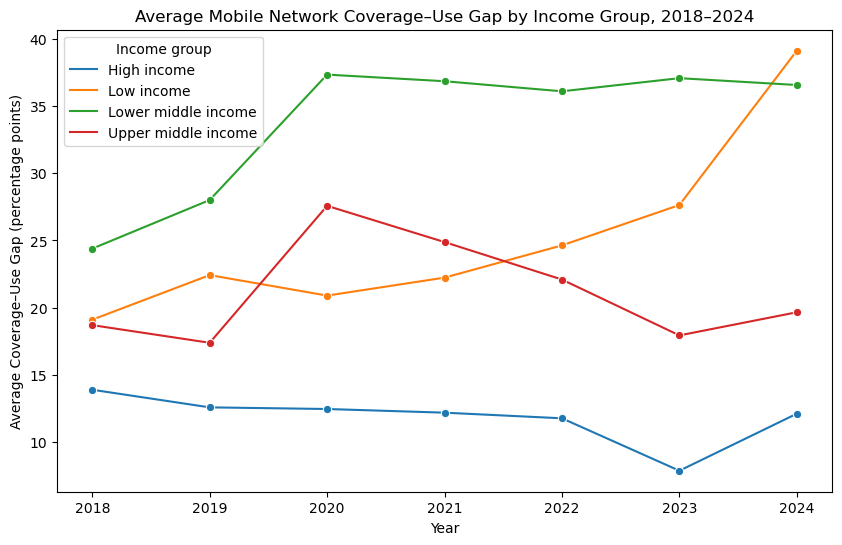

In [48]:

plt.figure(figsize=(10, 6))

sns.lineplot(
    data=gap_trend,
    x="Year",
    y="Coverage_Use_Gap",
    hue="Income group",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Coverage–Use Gap (percentage points)")
plt.title("Average Mobile Network Coverage–Use Gap by Income Group, 2018–2024")

plt.show()

In [49]:
analysis_df[
    (analysis_df["Income group"] == "Low income") &
    (analysis_df["Year"] == 2024)
][
    ["AreaName",
     "Percentage of the population covered by at least an LTE/WiMAX mobile network.",
     "Internet users (%)",
     "Coverage_Use_Gap"]
].sort_values("Coverage_Use_Gap", ascending=False)

,AreaName,Percentage of the population covered by at least an LTE/WiMAX mobile network.,Internet users (%),Coverage_Use_Gap
160,Uganda,82.000000,8.949831,73.050169
146,Rwanda,98.760000,31.703300,67.056700
41,Burkina Faso,63.700000,28.252701,35.447299
62,Ethiopia,44.000000,21.941299,22.058701
6,Afghanistan,37.324101,16.094999,21.229102
125,Madagascar,34.626694,18.677900,15.948793


## Internet useage over time

In [50]:
internet_trend = (
    analysis_df
    .groupby(["Income group", "Year"])["Internet users (%)"]
    .mean()
    .reset_index()
)

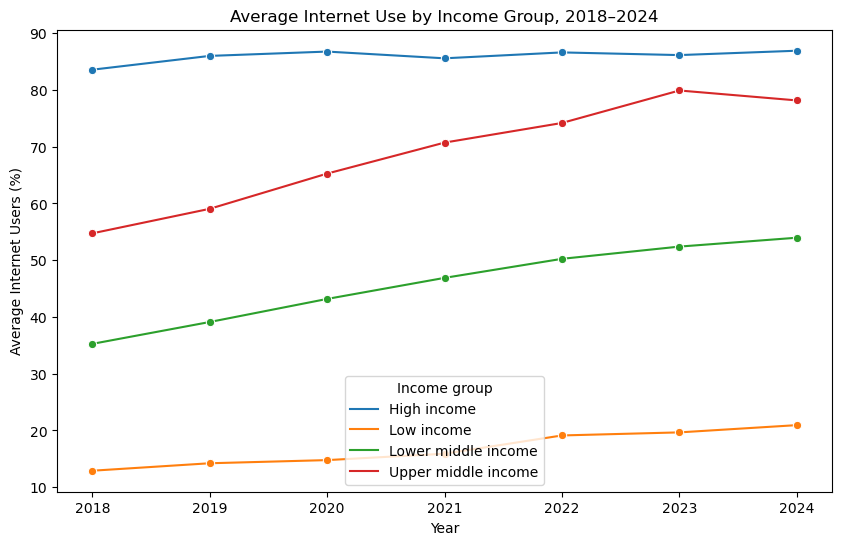

In [51]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=internet_trend,
    x="Year",
    y="Internet users (%)",
    hue="Income group",
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average Internet Users (%)")
plt.title("Average Internet Use by Income Group, 2018–2024")

plt.show()

## Broadband Subscriptions by income

In [52]:
broadband_by_income = (
    analysis_df
    .groupby("Income group")[
        ["Mobile_Broadband_per_100", "Fixed-broadband_per_100"]
    ]
    .mean()
    .round(2)
)

broadband_by_income

,Mobile_Broadband_per_100,Fixed-broadband_per_100
Income group,,
High income,127.71,34.58
Low income,36.01,0.20
Lower middle income,54.83,2.44
Upper middle income,79.10,12.42


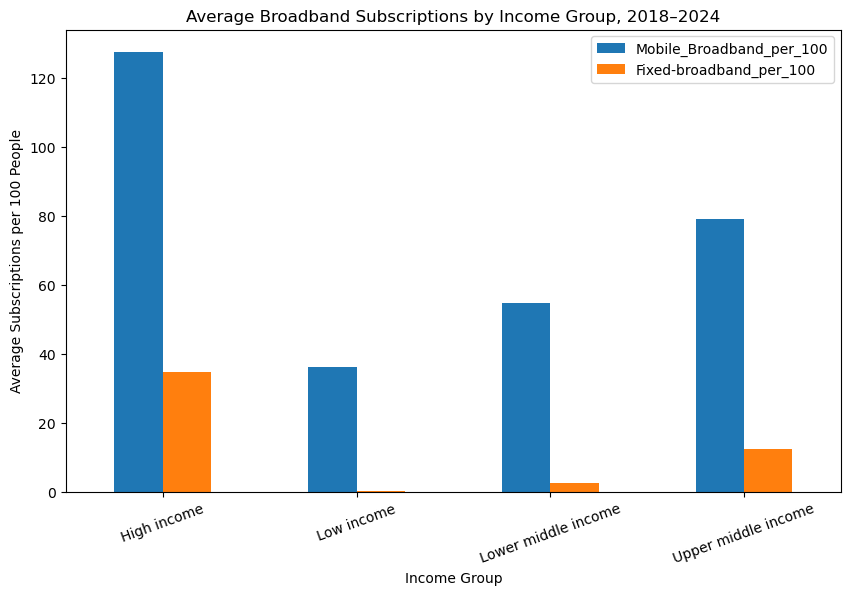

In [53]:
broadband_by_income.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.xlabel("Income Group")
plt.ylabel("Average Subscriptions per 100 People")
plt.title("Average Broadband Subscriptions by Income Group, 2018–2024")
plt.xticks(rotation=20)

plt.show()

## Summary Table

In [54]:
eda_summary = (
    analysis_df
    .groupby("Income group")[
        [
            "Electricity_Access",
            "Percentage of the population covered by at least an LTE/WiMAX mobile network.",
            "Internet users (%)",
            "Mobile_Broadband_per_100",
            "Fixed-broadband_per_100",
            "Coverage_Use_Gap"
        ]
    ]
    .mean()
    .round(2)
)

eda_summary

,Electricity_Access,Percentage of the population covered by at least an LTE/WiMAX mobile network.,Internet users (%),Mobile_Broadband_per_100,Fixed-broadband_per_100,Coverage_Use_Gap
Income group,,,,,,
High income,100.00,98.35,85.93,127.71,34.58,11.94
Low income,49.92,42.45,16.79,36.01,0.20,25.45
Lower middle income,74.96,80.52,45.86,54.83,2.44,33.96
Upper middle income,95.84,90.06,68.63,79.10,12.42,21.29
